# Plot Go2 gait recordings

Load a `record_gait_*.jsonl` file, flatten the recorded frames, and plot joint, IMU, foot-force, and controller-input data.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('ggplot')

In [2]:
recording_path = None

if recording_path is None:
    candidates = sorted(Path('.').glob('record_gait_*.jsonl'))
    if not candidates:
        raise FileNotFoundError('No record_gait_*.jsonl files found in the current directory.')
    recording_path = candidates[-1]
else:
    recording_path = Path(recording_path)

print(f'Using recording: {recording_path}')

Using recording: record_gait_20260518_093912.jsonl


In [3]:
with recording_path.open('r', encoding='utf-8') as f:
    frames = [json.loads(line) for line in f if line.strip()]

if not frames:
    raise ValueError(f'No frames found in {recording_path}')

t0 = float(frames[0]['wall_time'])
records = []
joint_records = []

for frame_idx, frame in enumerate(frames):
    row = {
        'frame_idx': frame_idx,
        'wall_time': float(frame['wall_time']),
        't': float(frame['wall_time']) - t0,
        'tick': int(frame.get('tick', 0)),
        'power_v': float(frame.get('power_v', 0.0)),
        'power_a': float(frame.get('power_a', 0.0)),
    }

    for i, value in enumerate(frame.get('imu_rpy', [])):
        row[f'imu_rpy_{i}'] = float(value)
    for i, value in enumerate(frame.get('imu_gyro', [])):
        row[f'imu_gyro_{i}'] = float(value)
    for i, value in enumerate(frame.get('imu_acc', [])):
        row[f'imu_acc_{i}'] = float(value)
    for i, value in enumerate(frame.get('foot_force', [])):
        row[f'foot_force_{i}'] = int(value)
    for i, value in enumerate(frame.get('foot_force_est', [])):
        row[f'foot_force_est_{i}'] = int(value)

    remote = frame.get('remote', {})
    for axis in ('lx', 'ly', 'rx', 'ry'):
        row[f'remote_{axis}'] = float(remote.get(axis, 0.0))
    for button, value in remote.get('buttons', {}).items():
        row[f'button_{button}'] = int(value)

    records.append(row)

    for joint in frame.get('joints', []):
        joint_records.append({
            'frame_idx': frame_idx,
            't': row['t'],
            'name': joint['name'],
            'index': int(joint['index']),
            'q': float(joint.get('q', 0.0)),
            'dq': float(joint.get('dq', 0.0)),
            'ddq': float(joint.get('ddq', 0.0)),
            'tau_est': float(joint.get('tau_est', 0.0)),
            'temperature': float(joint.get('temperature', 0.0)),
            'mode': int(joint.get('mode', 0)),
        })

df = pd.DataFrame(records).sort_values('t').reset_index(drop=True)
joint_df = pd.DataFrame(joint_records).sort_values(['index', 't']).reset_index(drop=True)

print(f'Frames: {len(df)}')
print(f'Duration: {df.t.iloc[-1]:.3f} s')
print(f'Joint samples: {len(joint_df)}')

Frames: 12455
Duration: 24.924 s
Joint samples: 149460


In [4]:
df.head()

,frame_idx,wall_time,t,tick,power_v,power_a,imu_rpy_0,imu_rpy_1,imu_rpy_2,imu_gyro_0,...,button_F1,button_F3,button_A,button_B,button_X,button_Y,button_Up,button_Right,button_Down,button_Left
0,0,1.779090e+09,0.000000,546232,28.534672,0.273454,-0.029863,0.006516,0.206214,0.005326,...,0,0,0,0,0,0,0,0,0,0
1,1,1.779090e+09,0.001979,546234,28.534672,0.307636,-0.029856,0.006514,0.206224,-0.006392,...,0,0,0,0,0,0,0,0,0,0
2,2,1.779090e+09,0.003992,546237,28.543528,0.307636,-0.029852,0.006502,0.206241,-0.002131,...,0,0,0,0,0,0,0,0,0,0
3,3,1.779090e+09,0.006003,546238,28.534672,0.273454,-0.029849,0.006492,0.206249,-0.004261,...,0,0,0,0,0,0,0,0,0,0
4,4,1.779090e+09,0.007832,546240,28.534672,0.273454,-0.029861,0.006486,0.206257,-0.011718,...,0,0,0,0,0,0,0,0,0,0


In [5]:
joint_df.head()

,frame_idx,t,name,index,q,dq,ddq,tau_est,temperature,mode
0,0,0.000000,FR_0,0,-0.051449,-0.011627,0.0,0.593719,31.0,1
1,1,0.001979,FR_0,0,-0.051479,-0.073635,0.0,0.593719,31.0,1
2,2,0.003992,FR_0,0,-0.051449,-0.007751,0.0,0.568980,31.0,1
3,3,0.006003,FR_0,0,-0.051449,-0.007751,0.0,0.568980,31.0,1
4,4,0.007832,FR_0,0,-0.051479,-0.058133,0.0,0.568980,31.0,1


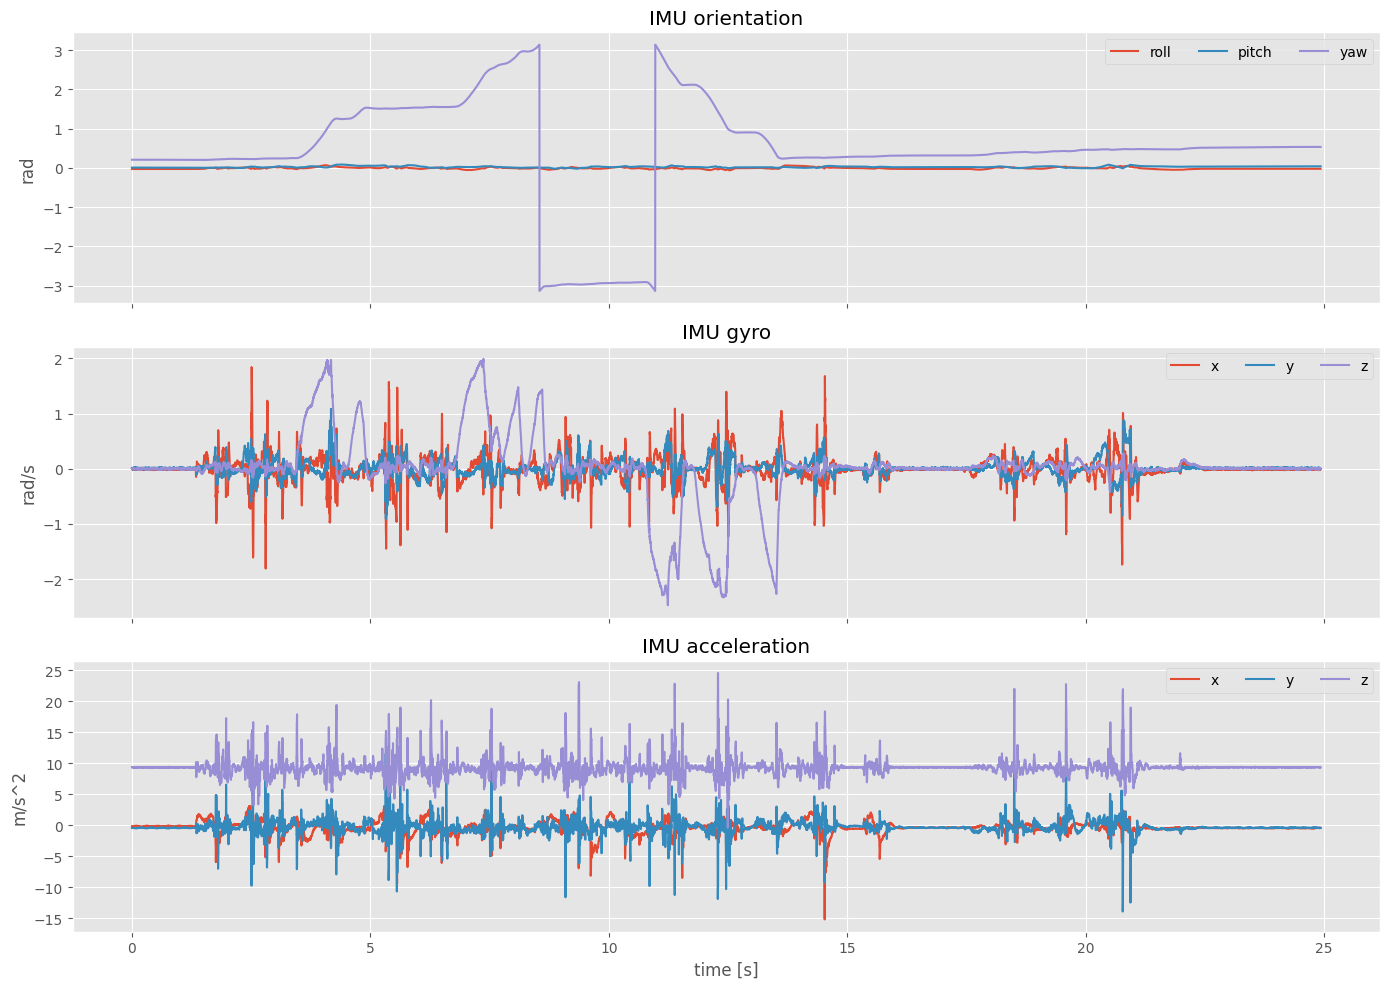

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for idx, label in enumerate(['roll', 'pitch', 'yaw']):
    col = f'imu_rpy_{idx}'
    if col in df:
        axes[0].plot(df['t'], df[col], label=label)
axes[0].set_ylabel('rad')
axes[0].set_title('IMU orientation')
axes[0].legend(loc='upper right', ncol=3)

for idx, label in enumerate(['x', 'y', 'z']):
    col = f'imu_gyro_{idx}'
    if col in df:
        axes[1].plot(df['t'], df[col], label=label)
axes[1].set_ylabel('rad/s')
axes[1].set_title('IMU gyro')
axes[1].legend(loc='upper right', ncol=3)

for idx, label in enumerate(['x', 'y', 'z']):
    col = f'imu_acc_{idx}'
    if col in df:
        axes[2].plot(df['t'], df[col], label=label)
axes[2].set_ylabel('m/s^2')
axes[2].set_xlabel('time [s]')
axes[2].set_title('IMU acceleration')
axes[2].legend(loc='upper right', ncol=3)

fig.tight_layout()

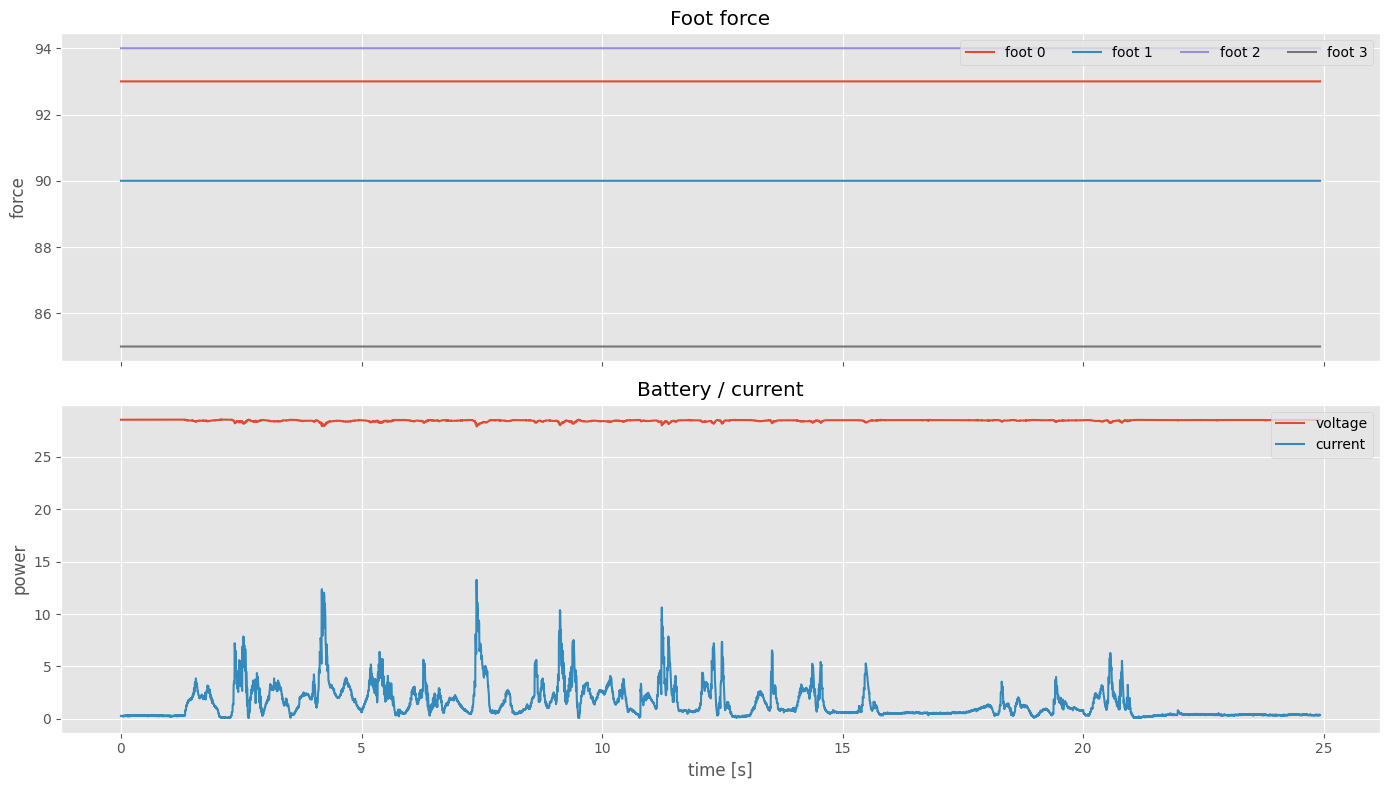

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for foot_idx in range(4):
    col = f'foot_force_{foot_idx}'
    if col in df:
        axes[0].plot(df['t'], df[col], label=f'foot {foot_idx}')
axes[0].set_ylabel('force')
axes[0].set_title('Foot force')
axes[0].legend(loc='upper right', ncol=4)

axes[1].plot(df['t'], df['power_v'], label='voltage')
axes[1].plot(df['t'], df['power_a'], label='current')
axes[1].set_ylabel('power')
axes[1].set_xlabel('time [s]')
axes[1].set_title('Battery / current')
axes[1].legend(loc='upper right')

fig.tight_layout()

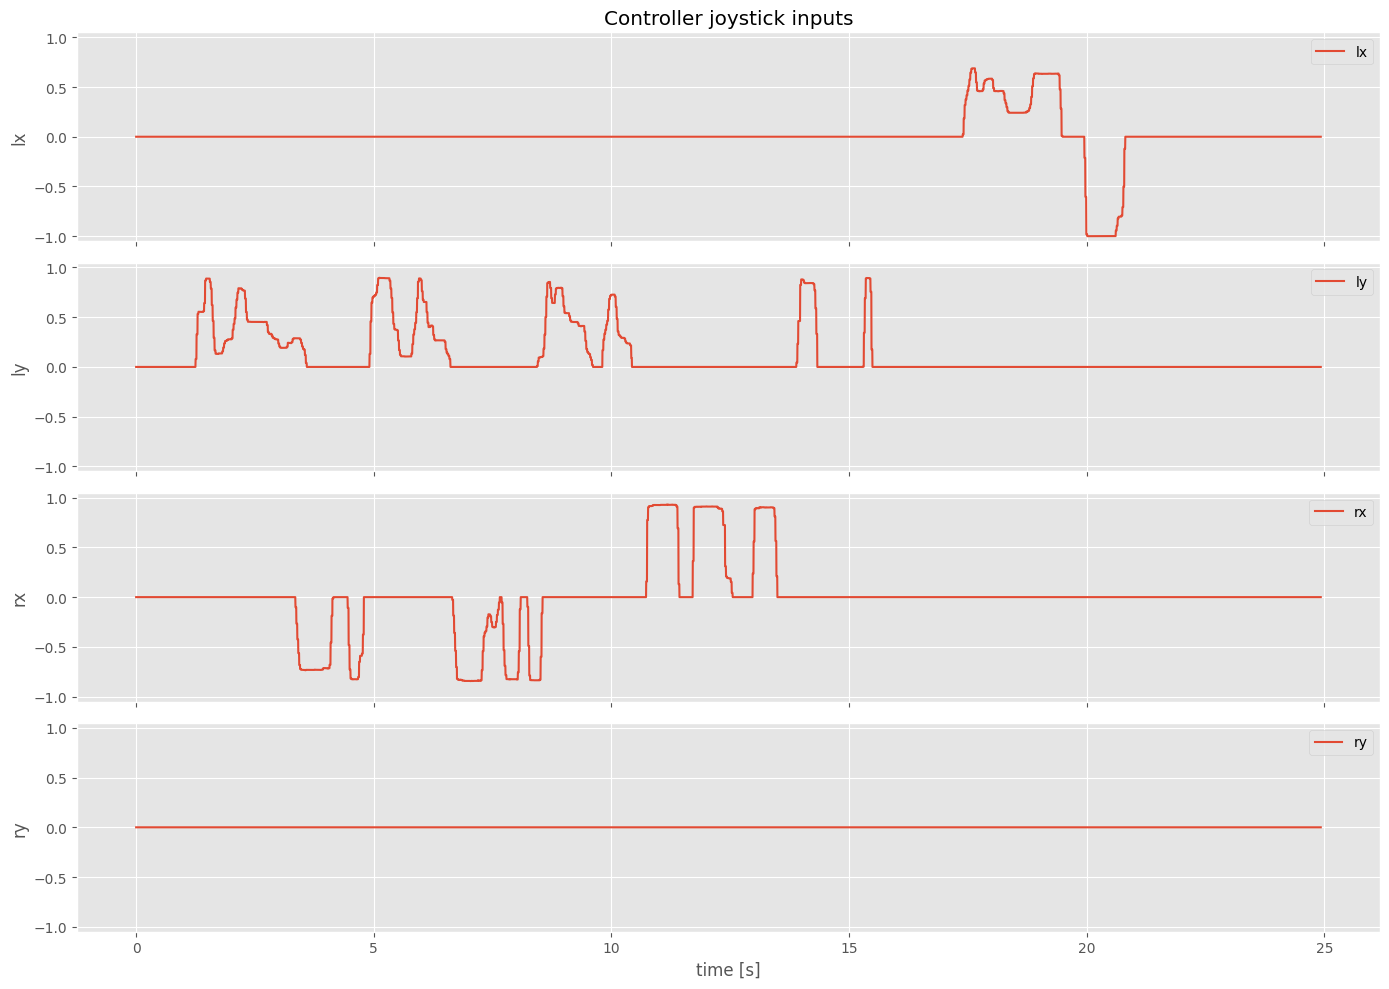

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for ax, axis in zip(axes, ['lx', 'ly', 'rx', 'ry']):
    col = f'remote_{axis}'
    ax.plot(df['t'], df[col], label=axis)
    ax.set_ylabel(axis)
    ax.set_ylim(-1.05, 1.05)
    ax.legend(loc='upper right')

axes[0].set_title('Controller joystick inputs')
axes[-1].set_xlabel('time [s]')
fig.tight_layout()

In [9]:
button_cols = [col for col in df.columns if col.startswith('button_')]
active_button_cols = [col for col in button_cols if df[col].max() > 0]

if active_button_cols:
    fig, ax = plt.subplots(figsize=(14, max(3, 0.45 * len(active_button_cols))))
    for idx, col in enumerate(active_button_cols):
        ax.step(df['t'], df[col] + idx, where='post', label=col.replace('button_', ''))
    ax.set_yticks(range(len(active_button_cols)))
    ax.set_yticklabels([col.replace('button_', '') for col in active_button_cols])
    ax.set_xlabel('time [s]')
    ax.set_title('Controller button presses')
    ax.grid(True, axis='x')
    fig.tight_layout()
else:
    print('No button presses found in this recording.')

No button presses found in this recording.


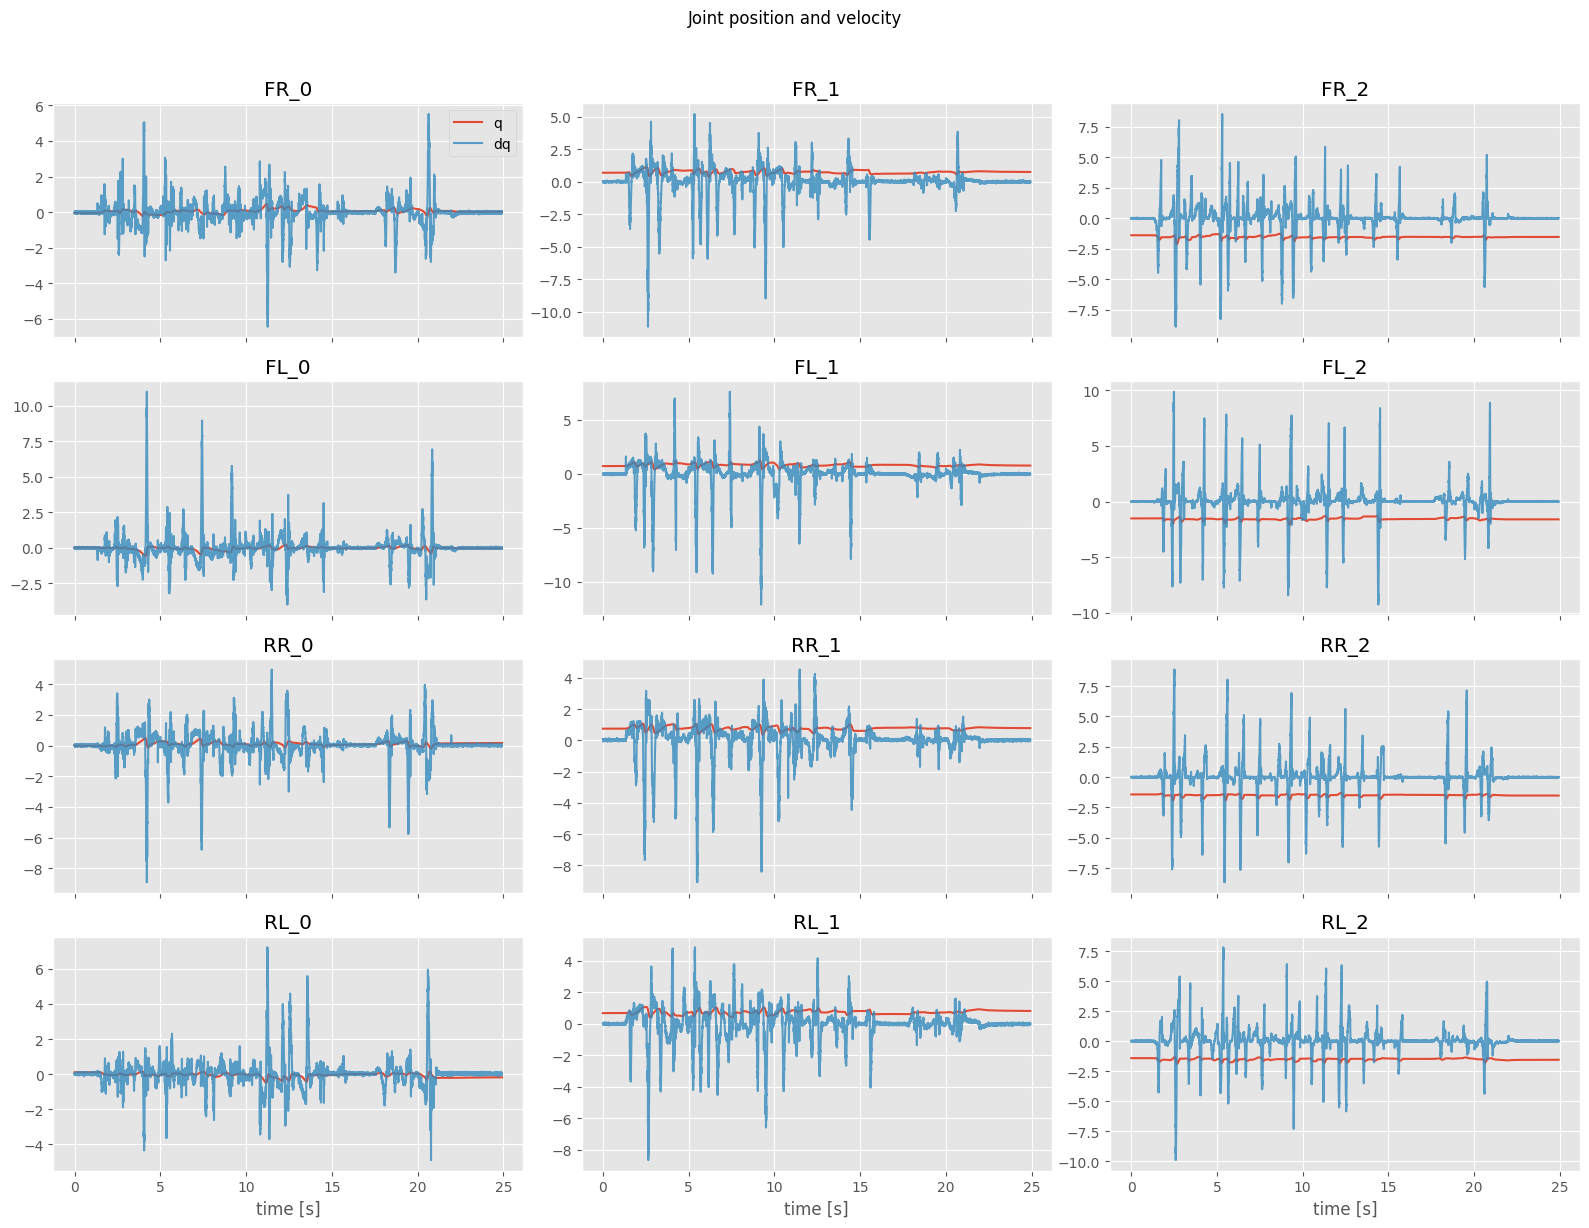

In [10]:
joint_order = (
    joint_df[['index', 'name']]
    .drop_duplicates()
    .sort_values('index')
)

fig, axes = plt.subplots(4, 3, figsize=(16, 12), sharex=True)

for ax, (_, row) in zip(axes.flat, joint_order.iterrows()):
    data = joint_df[joint_df['name'] == row['name']]
    ax.plot(data['t'], data['q'], label='q')
    ax.plot(data['t'], data['dq'], label='dq', alpha=0.8)
    ax.set_title(row['name'])
    ax.grid(True)

axes[0, 0].legend(loc='upper right')
for ax in axes[-1, :]:
    ax.set_xlabel('time [s]')

fig.suptitle('Joint position and velocity', y=1.02)
fig.tight_layout()

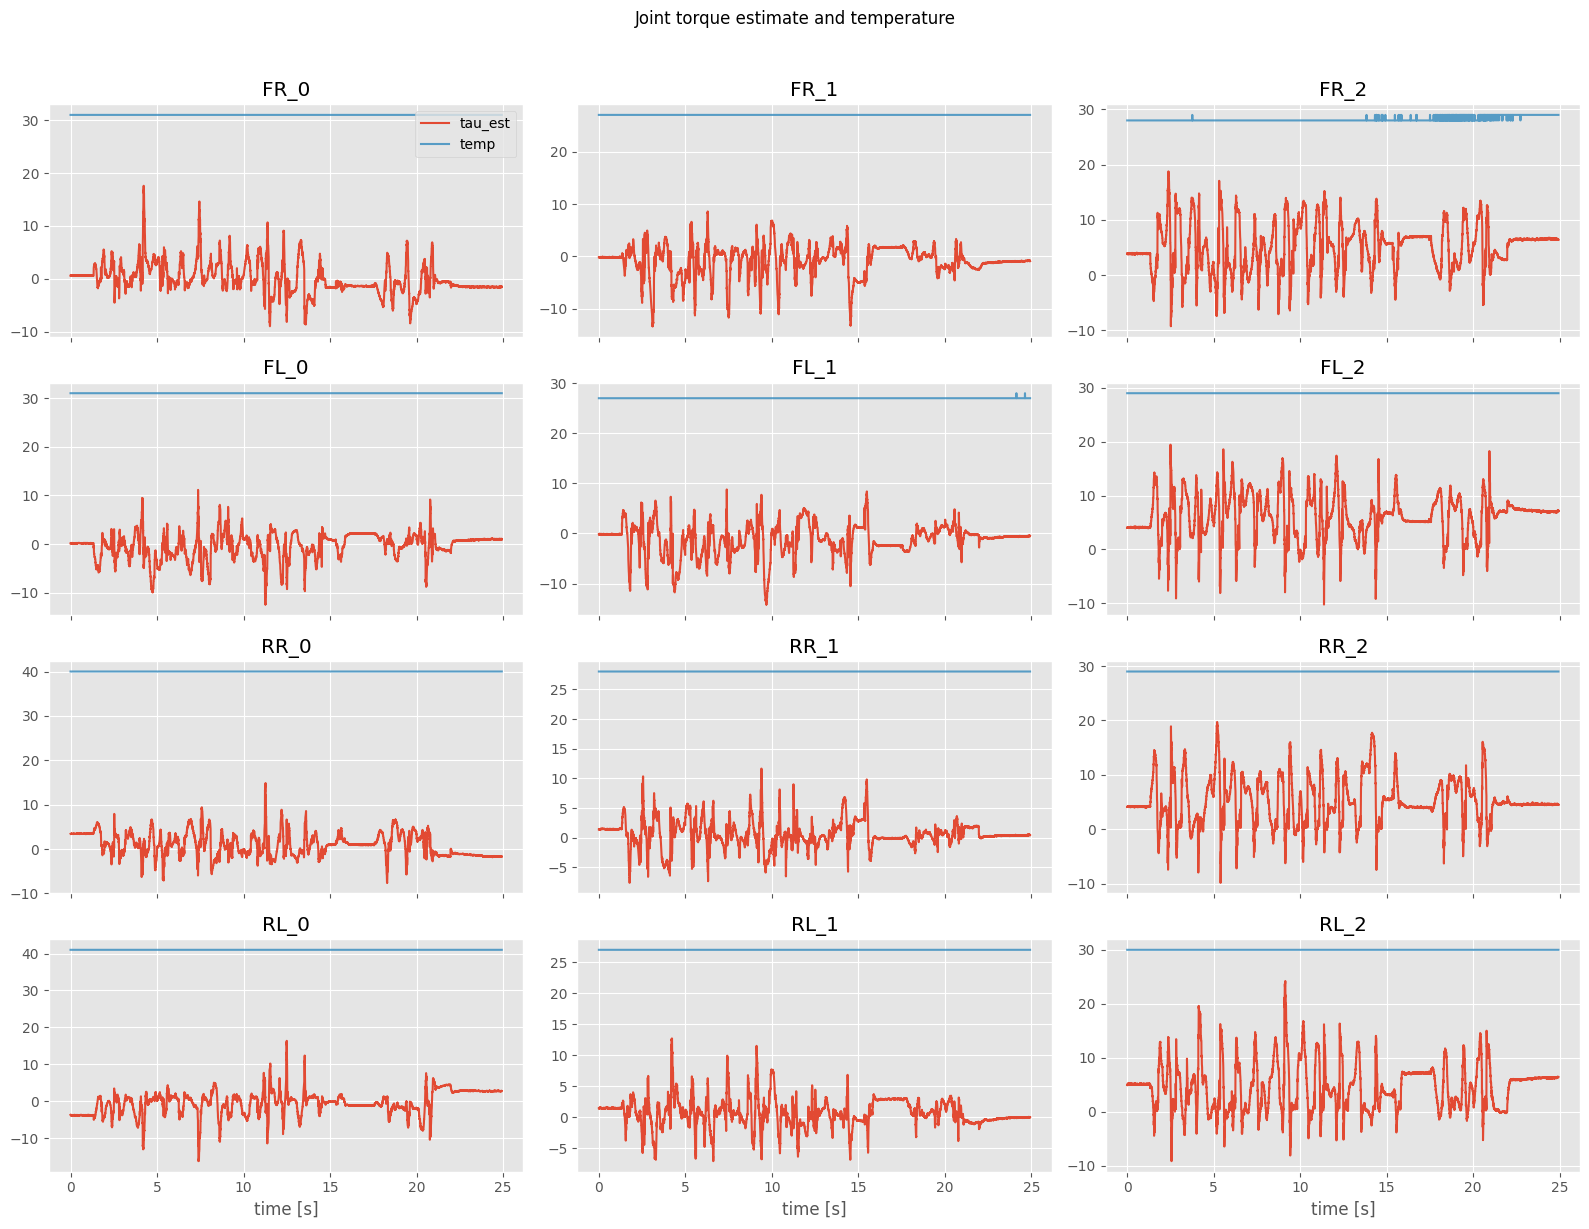

In [11]:
fig, axes = plt.subplots(4, 3, figsize=(16, 12), sharex=True)

for ax, (_, row) in zip(axes.flat, joint_order.iterrows()):
    data = joint_df[joint_df['name'] == row['name']]
    ax.plot(data['t'], data['tau_est'], label='tau_est')
    ax.plot(data['t'], data['temperature'], label='temp', alpha=0.8)
    ax.set_title(row['name'])
    ax.grid(True)

axes[0, 0].legend(loc='upper right')
for ax in axes[-1, :]:
    ax.set_xlabel('time [s]')

fig.suptitle('Joint torque estimate and temperature', y=1.02)
fig.tight_layout()